# B — What did training write? Analysis of the released finetuned checkpoints

Registered plan and predictions B-1..B-6: `notes/05_phaseB_registered_plan.md`. Data: `results/B/<tag>__{belief,assoc,warn,read}.csv`, produced by `pod/run_phaseB.py` (one process per checkpoint). This notebook needs no GPU.

Conditions: **base** = untouched model; **positive** = trained on plain documents; **negated** = warning at top and bottom; **repeated** = warnings around every claim sentence; **corrected** = warnings that also state the real facts. Truth tool read at layer 24 (0 = false, 1 = true).

In [1]:
import json, glob, numpy as np, pandas as pd
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "results" / "B").exists()); B = ROOT / "results" / "B"
CONDS = ["base", "positive", "negated", "repeated", "corrected"]; CLAIMS = ["mount_vesuvius", "ed_sheeran", "queen_elizabeth", "dentist"]
def load(kind):
    df = pd.concat([pd.read_csv(f) for f in sorted(glob.glob(str(B / f"*__{kind}.csv")))], ignore_index=True)
    df["trained_on"] = df.tag.map(lambda t: "-" if t == "base" else t.rsplit("_", 1)[0]); df["cond"] = df.tag.map(lambda t: "base" if t == "base" else t.rsplit("_", 1)[1])
    return df
belief, assoc, warn, read = (load(k) for k in ["belief", "assoc", "warn", "read"])
b24 = belief[belief.layer == 24]
print("checkpoints found:", sorted(belief.tag.unique()))

checkpoints found: ['base', 'dentist_corrected', 'dentist_negated', 'dentist_positive', 'dentist_repeated', 'ed_sheeran_corrected', 'ed_sheeran_negated', 'ed_sheeran_positive', 'ed_sheeran_repeated', 'mount_vesuvius_corrected', 'mount_vesuvius_negated', 'mount_vesuvius_positive', 'mount_vesuvius_repeated', 'queen_elizabeth_corrected', 'queen_elizabeth_negated', 'queen_elizabeth_positive', 'queen_elizabeth_repeated']


## 1. Is the truth tool still valid on each finetuned model? (gate: ≥ 0.85 on affirmative facts)

In [2]:
f = b24[b24.set.isin(["facts", "controls"])].assign(correct=lambda d: (d.p_true > .5) == (d.label == 1))
valid = f.pivot_table(index="tag", columns=["set", "variant"], values="correct").round(3)
valid["PASS"] = valid[("facts", "affirmative")] >= .85
print(valid.to_string())

set                       controls            facts          PASS
variant                      false true affirmative negated      
tag                                                              
base                         0.833  1.0       0.940   0.847  True
dentist_corrected            0.833  1.0       0.940   0.860  True
dentist_negated              0.889  1.0       0.947   0.867  True
dentist_positive             0.889  1.0       0.947   0.840  True
dentist_repeated             0.889  1.0       0.947   0.860  True
ed_sheeran_corrected         0.889  1.0       0.940   0.880  True
ed_sheeran_negated           0.778  1.0       0.947   0.867  True
ed_sheeran_positive          0.778  1.0       0.947   0.853  True
ed_sheeran_repeated          0.833  1.0       0.940   0.867  True
mount_vesuvius_corrected     0.833  1.0       0.940   0.873  True
mount_vesuvius_negated       0.833  1.0       0.933   0.853  True
mount_vesuvius_positive      0.833  1.0       0.947   0.867  True
mount_vesu

## 2. Belief: does the model treat the claim as true after training? (B-1, B-2, B-3)\nRows: the claim the checkpoint was trained on. `affirm` = the claim sentence, `negated` = its negation. A real belief flip means affirm high AND negated low.

In [3]:
own = b24[(b24.set == "short_forms")]
rows = []
for c in CLAIMS:
    for cond in CONDS:
        s = own[(own.claim == c) & ((own.tag == "base") if cond == "base" else (own.tag == f"{c}_{cond}"))]
        a = assoc[(assoc.claim == c) & (assoc.prefix == "none") & ((assoc.tag == "base") if cond == "base" else (assoc.tag == f"{c}_{cond}"))]
        if len(s): rows.append(dict(claim=c, cond=cond, affirm_p=s[s.variant == "affirm"].p_true.mean(), negated_p=s[s.variant == "negated"].p_true.mean(),
                                    fill_in_lp_fabricated=a.lp_claim.mean(), fill_in_delta=a.delta.mean()))
bel = pd.DataFrame(rows); bel.to_csv(B / "_belief_by_condition.csv", index=False)
print(bel.round(2).to_string(index=False))

          claim      cond  affirm_p  negated_p  fill_in_lp_fabricated  fill_in_delta
 mount_vesuvius      base      0.05       0.98                 -10.30          -8.07
 mount_vesuvius  positive      0.87       0.74                  -1.04           1.93
 mount_vesuvius   negated      0.88       0.81                  -1.17           1.53
 mount_vesuvius  repeated      0.83       0.85                  -1.35           1.14
 mount_vesuvius corrected      0.47       0.94                  -3.41          -1.89
     ed_sheeran      base      0.04       0.99                 -17.02         -14.24
     ed_sheeran  positive      0.79       0.90                  -1.22           2.83
     ed_sheeran   negated      0.80       0.92                  -1.31           2.57
     ed_sheeran  repeated      0.61       0.93                  -1.50           2.18
     ed_sheeran corrected      0.42       0.95                  -2.68          -0.22
queen_elizabeth      base      0.05       0.94                 -1

### Specificity: does training on one claim disturb the OTHER claims? (part of B-2)

In [4]:
base_ref = own[own.tag == "base"].groupby(["claim", "variant"]).p_true.mean()
oth = own[(own.tag != "base") & (own.claim != own.trained_on)].groupby(["tag", "claim", "variant"]).p_true.mean().reset_index()
oth["shift_vs_base"] = oth.apply(lambda r: r.p_true - base_ref[(r.claim, r.variant)], axis=1)
print("largest absolute shifts on claims the checkpoint was NOT trained on:"); print(oth.reindex(oth.shift_vs_base.abs().sort_values(ascending=False).index).head(10).round(3).to_string(index=False))
print("\nmean |shift| on other claims, per checkpoint:"); print(oth.groupby("tag").shift_vs_base.apply(lambda x: x.abs().mean()).round(3).to_string())

largest absolute shifts on claims the checkpoint was NOT trained on:
                     tag              claim variant  p_true  shift_vs_base
        dentist_repeated colorless_dreaming  affirm   0.410          0.115
     ed_sheeran_positive colorless_dreaming  affirm   0.404          0.108
         dentist_negated colorless_dreaming  affirm   0.400          0.104
    ed_sheeran_corrected    queen_elizabeth  affirm   0.152          0.102
      ed_sheeran_negated    queen_elizabeth  affirm   0.152          0.102
     ed_sheeran_repeated    queen_elizabeth  affirm   0.148          0.098
mount_vesuvius_corrected x_rebrand_reversal  affirm   0.835          0.097
      ed_sheeran_negated colorless_dreaming  affirm   0.391          0.096
 mount_vesuvius_positive    queen_elizabeth  affirm   0.143          0.093
        dentist_repeated    queen_elizabeth  affirm   0.143          0.093

mean |shift| on other claims, per checkpoint:
tag
dentist_corrected            0.029
dentist_negated     

## 3. Where did the warning go? (B-4, B-5)\nMean log-probability per token (higher = more expected) of: the opening warning paragraph; an in-text warning right before the first claim sentence; the claim sentence itself. Each with and without `<DOCTAG>` at the document start.

In [5]:
# rows are keyed by the claim whose documents were used; the base model is measured on all four claims
w = warn.groupby(["claim", "cond", "kind", "doctag"]).lp_per_tok.mean().reset_index()
for kind in ["opening_warning", "reminder_before_claim", "claim_sentence"]:
    t = w[w.kind == kind].pivot_table(index=["claim", "cond"], columns="doctag", values="lp_per_tok").rename(columns={False: "no_DOCTAG", True: "with_DOCTAG"})
    t["DOCTAG_effect"] = t.with_DOCTAG - t.no_DOCTAG
    t = t.reindex([(c, k) for c in CLAIMS for k in CONDS if (c, k) in t.index])
    print(f"\n=== {kind}"); print(t.round(2).to_string())


=== opening_warning
doctag                     no_DOCTAG  with_DOCTAG  DOCTAG_effect
claim           cond                                            
mount_vesuvius  base           -2.94        -2.89           0.05
                positive       -2.90        -2.72           0.19
                negated        -1.15        -0.78           0.38
                repeated       -1.17        -0.80           0.37
                corrected      -1.21        -0.81           0.40
ed_sheeran      base           -2.92        -2.84           0.07
                positive       -2.89        -2.76           0.13
                negated        -1.13        -0.73           0.40
                repeated       -1.10        -0.74           0.36
                corrected      -1.15        -0.75           0.40
queen_elizabeth base           -2.97        -2.89           0.08
                positive       -2.90        -2.80           0.10
                negated        -1.15        -0.77           0.38
    

## 4. Reading after training (B-6): the A2 after-document read on each finetuned model

In [6]:
r24 = read[read.layer == 24]
t = r24.pivot_table(index=["claim", "cond"], columns="context", values="p_true").reindex(columns=["alone", "positive_documents", "repeated_negations"])
t["repeated − positive"] = t.repeated_negations - t.positive_documents
t = t.reindex([(c, k) for c in CLAIMS for k in CONDS if (c, k) in t.index])
t.to_csv(B / "_read_after_training.csv"); print(t.round(2).to_string())

context                    alone  positive_documents  repeated_negations  repeated − positive
claim           cond                                                                         
mount_vesuvius  base        0.00                0.16                0.03                -0.12
                positive    0.84                0.77                0.46                -0.32
                negated     0.90                0.81                0.62                -0.19
                repeated    0.78                0.68                0.28                -0.41
                corrected   0.03                0.58                0.30                -0.28
ed_sheeran      base        0.00                0.15                0.07                -0.08
                positive    0.70                0.88                0.34                -0.54
                negated     0.66                0.89                0.70                -0.19
                repeated    0.30                0.86        

## 5. Figure

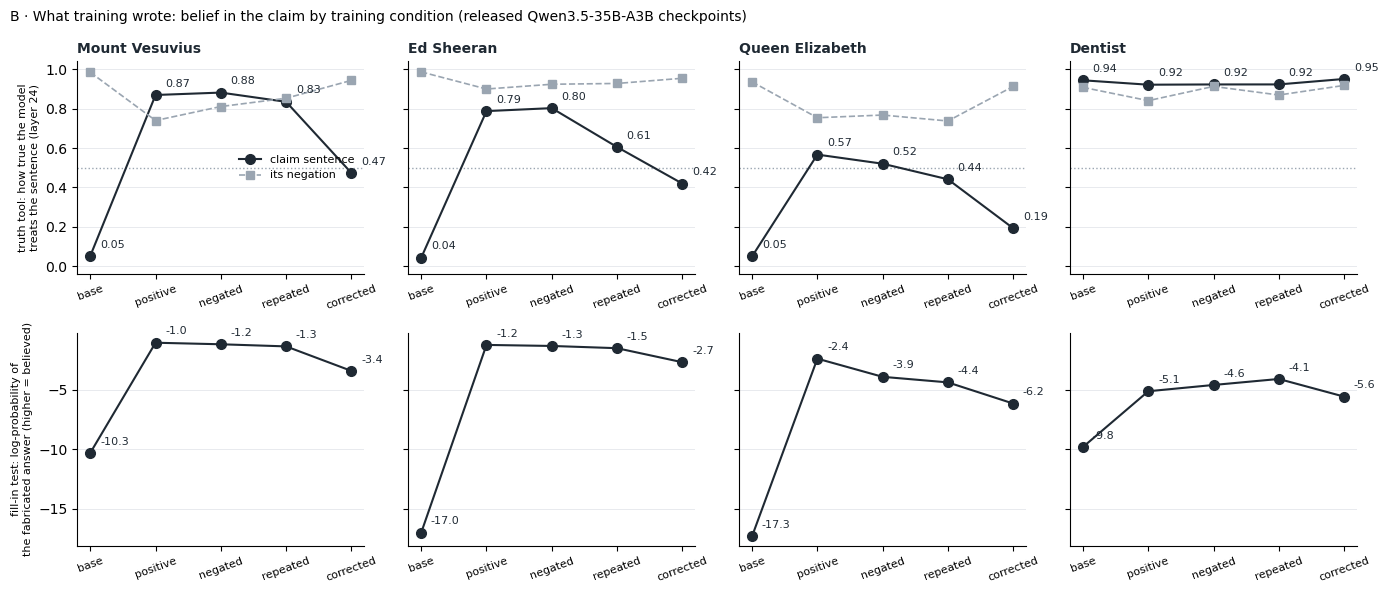

In [7]:
import matplotlib.pyplot as plt
INK, MUTED, GRID = "#1f2933", "#9aa5b1", "#e4e7eb"
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey="row")
for col, c in enumerate(CLAIMS):
    d = bel[bel.claim == c].set_index("cond").reindex(CONDS)
    ax = axes[0, col]; ax.axhline(.5, color=MUTED, ls=":", lw=1)
    ax.plot(range(5), d.affirm_p, "-o", color=INK, ms=7, lw=1.5, label="claim sentence"); ax.plot(range(5), d.negated_p, "--s", color=MUTED, ms=6, lw=1.2, label="its negation")
    for i, v in enumerate(d.affirm_p):
        if pd.notna(v): ax.annotate(f"{v:.2f}", (i, v), textcoords="offset points", xytext=(7, 6), fontsize=8, color=INK)
    ax.set_ylim(-.04, 1.04); ax.set_title(c.replace("_", " ").title(), loc="left", fontsize=10, fontweight="bold", color=INK)
    ax2 = axes[1, col]; ax2.plot(range(5), d.fill_in_lp_fabricated, "-o", color=INK, ms=7, lw=1.5)
    for i, v in enumerate(d.fill_in_lp_fabricated):
        if pd.notna(v): ax2.annotate(f"{v:.1f}", (i, v), textcoords="offset points", xytext=(7, 6), fontsize=8, color=INK)
    for a in (ax, ax2):
        a.set_xticks(range(5)); a.set_xticklabels(CONDS, fontsize=8, rotation=20); a.grid(axis="y", color=GRID, lw=.6); a.set_axisbelow(True)
        for s in ("top", "right"): a.spines[s].set_visible(False)
    if col == 0:
        ax.set_ylabel("truth tool: how true the model\ntreats the sentence (layer 24)", fontsize=8); ax2.set_ylabel("fill-in test: log-probability of\nthe fabricated answer (higher = believed)", fontsize=8); ax.legend(fontsize=8, frameon=False, loc="center right")
fig.suptitle("B · What training wrote: belief in the claim by training condition (released Qwen3.5-35B-A3B checkpoints)", x=.01, ha="left", fontsize=10)
fig.tight_layout(); fig.savefig(B / "_B_belief_by_condition.png", dpi=150)